# Cross-country comparison

This notebook discovers `*_clean.csv` files in the repository `Data/` folder, loads them, computes summary statistics for core solar metrics (GHI, DNI, DHI), produces boxplots and a rank-by-average plot, and runs simple statistical tests (ANOVA / Kruskal-Wallis) for GHI.

It is intentionally robust to the Jupyter kernel CWD by walking parent directories to find `Data/` at repo root.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
sns.set(style='whitegrid')

def find_data_root():
    curr = Path.cwd().resolve()
    for parent in [curr] + list(curr.parents):
        if (parent / 'Data').is_dir():
            return parent / 'Data'
    # fallback: relative path
    return Path('./Data').resolve()

DATA_ROOT = find_data_root()
print('Using Data root:', DATA_ROOT)

Using Data root: C:\Users\hp\Desktop\Ten Academy\weak 0\Assigniments\TEST\solar-challenge-week0\Data


In [ ]:
# discover *_clean.csv files
files = list(DATA_ROOT.glob('*_clean.csv'))
print('Found cleaned CSVs:')
for p in files:
    print('-', p.name)

# load them into dataframes dict
dfs = {}
for p in files:
    try:
        df = pd.read_csv(p)
        # attempt to infer country from filename (prefix before _clean)
        country = p.name.split('_clean')[0] or p.stem
        df['country'] = country
        dfs[country] = df
    except Exception as e:
        print('Failed to load', p.name, e)

print('Loaded countries:', list(dfs.keys()))
for k,v in dfs.items():
    print(k, v.shape)

In [ ]:
# concat available dataframes
if len(dfs) == 0:
    raise RuntimeError('No *_clean.csv files found in Data/. Add cleaned CSVs and re-run.')

merged = pd.concat(dfs.values(), ignore_index=True, sort=False)
print('Merged shape:', merged.shape)

# standard metrics we care about
metrics = ['GHI','DNI','DHI']
present = [m for m in metrics if m in merged.columns]
print('Metrics present in merged data:', present)

def summary_table(df, metrics):
    present = [m for m in metrics if m in df.columns]
    if not present:
        return pd.DataFrame()
    summary = df.groupby('country')[present].agg(['mean','median','std']).round(3)
    summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
    return summary.reset_index()

summary = summary_table(merged, metrics)
display(summary)
# save summary if present
out_dir = Path('outputs')
out_dir.mkdir(exist_ok=True)
if not summary.empty:
    summary.to_csv(out_dir / 'summary_stats.csv', index=False)
    print('Saved summary to', out_dir / 'summary_stats.csv')

In [ ]:
# boxplots per metric by country and a ranking plot for avg GHI
import matplotlib.pyplot as plt
import seaborn as sns

for metric in metrics:
    if metric not in merged.columns:
        print('Skipping', metric, '(not present)')
        continue
    plt.figure(figsize=(8,4))
    sns.boxplot(x='country', y=metric, data=merged, palette='Set2')
    plt.title(f'Boxplot of {metric} by country')
    plt.tight_layout()
    fp = out_dir / f'boxplot_{metric}.png'
    plt.savefig(fp, dpi=150)
    print('Saved', fp)
    plt.show()

# ranking by average GHI
if 'GHI' in merged.columns:
    avg = merged.groupby('country')['GHI'].mean().sort_values(ascending=False)
    plt.figure(figsize=(6,3))
    sns.barplot(x=avg.values, y=avg.index, palette='viridis')
    plt.xlabel('Average GHI')
    plt.title('Countries ranked by average GHI')
    plt.tight_layout()
    fp = out_dir / 'rank_by_avg_GHI.png'
    plt.savefig(fp, dpi=150)
    print('Saved', fp)
    plt.show()

In [ ]:
# simple statistical tests for GHI across countries
if 'GHI' not in merged.columns:
    print('GHI not present in merged data: skipping statistical tests')
else:
    groups = [g.dropna() for _, g in merged.groupby('country')['GHI']]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) < 2:
        print('Not enough groups/data for statistical testing')
    else:
        try:
            f_stat, p_anova = stats.f_oneway(*groups)
            print('ANOVA f-stat, p-value:', f_stat, p_anova)
        except Exception as e:
            print('ANOVA failed:', e)
        try:
            h, p_kruskal = stats.kruskal(*groups)
            print('Kruskal-Wallis H, p-value:', h, p_kruskal)
        except Exception as e:
            print('Kruskal-Wallis failed:', e)

### Notes and next steps
- If a country CSV lacks the solar columns (GHI/DNI/DHI), those metrics will be skipped and show NaNs in the summary. Provide cleaned files with expected columns to enable full comparison.
- Consider running `scripts/run_compare.py` (already present) to produce outputs/ in batch.
- For a dashboard, the `app/` Streamlit scaffold can read the saved `outputs/summary_stats.csv` and images.

Resolved Data root: C:\Users\hp\Desktop\Ten Academy\weak 0\Assigniments\TEST\solar-challenge-week0\Data
Found file for canada: C:\Users\hp\Desktop\Ten Academy\weak 0\Assigniments\TEST\solar-challenge-week0\Data\canada_clean.csv
Found file for ethiopia: C:\Users\hp\Desktop\Ten Academy\weak 0\Assigniments\TEST\solar-challenge-week0\Data\ethiopia_clean.csv
Loaded canada: (6, 3)
Loaded ethiopia: (3, 12)


Merged shape: (9, 16)


,Month,Revenue,Units Sold,country,Timestamp,GHI,DNI,DHI,ModA,ModB,WS,WSgust,Tamb,RH,WD,Cleaning
0,January,48000.0,490.0,canada,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,February,51000.0,510.0,canada,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,March,65000.0,610.0,canada,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,April,62000.0,580.0,canada,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,May,61000.0,600.0,canada,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,country,GHI_mean,GHI_median,GHI_std,DNI_mean,DNI_median,DNI_std,DHI_mean,DHI_median,DHI_std
0,canada,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ethiopia,266.667,50.0,419.325,210.0,30.0,338.083,56.667,20.0,81.445


C:\Users\hp\AppData\Local\Temp\ipykernel_17172\2186889870.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='country', y=metric, data=merged, palette='Set2')


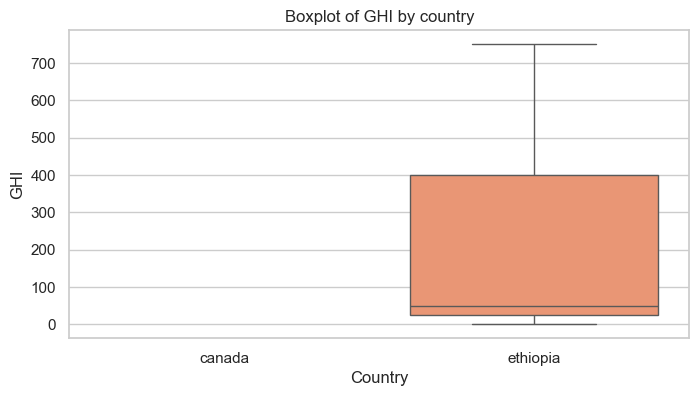

C:\Users\hp\AppData\Local\Temp\ipykernel_17172\2186889870.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='country', y=metric, data=merged, palette='Set2')


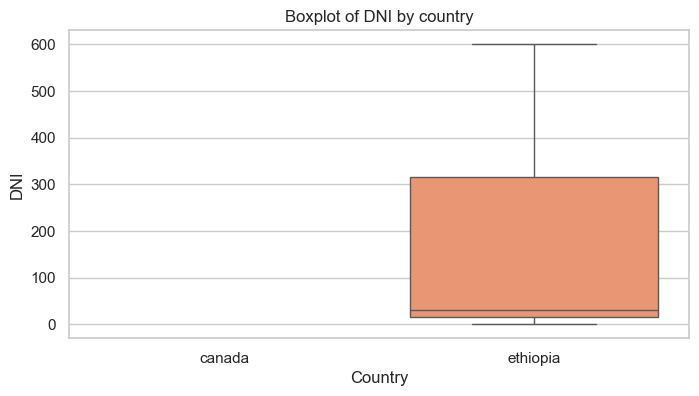

C:\Users\hp\AppData\Local\Temp\ipykernel_17172\2186889870.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='country', y=metric, data=merged, palette='Set2')


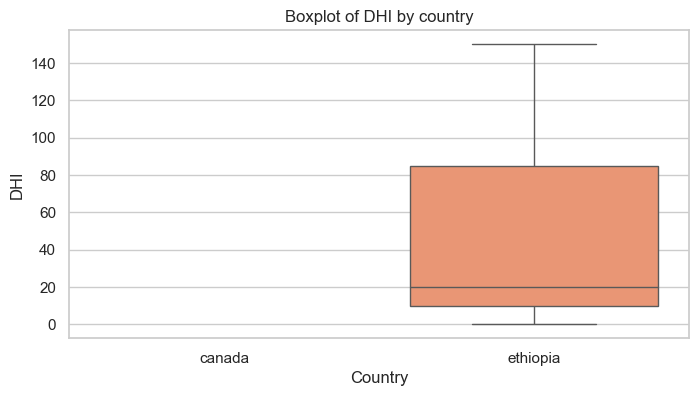

Not enough groups/data for statistical testing. Need at least 2 countries with GHI data.


C:\Users\hp\AppData\Local\Temp\ipykernel_17172\894769043.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg.values, y=avg.index, palette='viridis')


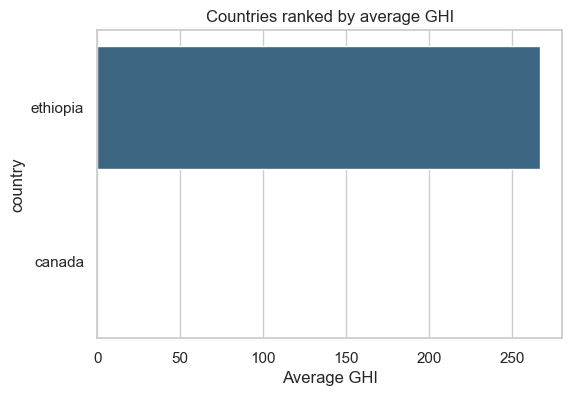